# 06 · Latencia, VRAM y coste por análisis

Medimos el sistema completo en el portátil de desarrollo, tal y como lo usaría el cliente:

* **Latencia** de cada flujo, separando el **veredicto** (semáforo y explicación) de las **salidas
  multimedia** (voz, infografía, vídeo), que llegan después de forma progresiva.
* **VRAM** a lo largo del tiempo. Muestreamos `nvidia-smi` cada 0,25 s porque Ollama es otro proceso y
  `torch.cuda` no ve su memoria.
* **Energía** por análisis a partir de la potencia que reporta la GPU, que alimenta el cálculo de costes del
  notebook 00.

Cada flujo se ejecuta dos veces: la primera **en frío** (cargando modelos) y la segunda **en caliente**, que
es la experiencia normal con la aplicación ya arrancada (la aplicación precarga los modelos al iniciar).

In [1]:
import json
import platform
import subprocess
import sys
import threading
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from diputado import config

config.ensure_dirs()
config.ensure_ffmpeg_on_path()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import Markdown, display

from diputado.ai import ollama_server
from diputado.ai.gpu import HAS_CUDA, vram_gb
from diputado.core import pipeline
from diputado.core.schemas import CaseInput
from diputado.data import demo_cases

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ollama_server.ensure_server(install_if_missing=False)
pipeline._store = lambda r: None


def gpu_name() -> str:
    try:
        return subprocess.check_output(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True).strip()
    except Exception:
        return "sin GPU NVIDIA"


hardware = f"{gpu_name()} ({vram_gb():.0f} GB) · {platform.processor() or platform.machine()} · {psutil.virtual_memory().total / 2**30:.0f} GB RAM"
print(hardware)

NVIDIA GeForce RTX 4070 Laptop GPU (8 GB) · AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD · 31 GB RAM


## 1. Monitor de GPU en segundo plano

In [2]:
class GPUMonitor:
    def __init__(self, period=0.25):
        self.period, self.samples, self.marks, self._stop = period, [], [], threading.Event()

    def _run(self):
        while not self._stop.is_set():
            try:
                out = subprocess.check_output(["nvidia-smi", "--query-gpu=memory.used,power.draw,utilization.gpu",
                                               "--format=csv,noheader,nounits"], text=True, timeout=2)
                mem, pw, ut = [float(x) for x in out.strip().split(", ")]
                self.samples.append((time.perf_counter(), mem / 1024, pw, ut))
            except Exception:
                pass
            time.sleep(self.period)

    def start(self):
        self.t0 = time.perf_counter()
        threading.Thread(target=self._run, daemon=True).start()
        return self

    def mark(self, label):
        self.marks.append((time.perf_counter(), label))

    def stop(self):
        self._stop.set()
        time.sleep(self.period * 2)

    def energy_wh(self, t_start, t_end):
        s = [(t, p) for t, _, p, _ in self.samples if t_start <= t <= t_end]
        if len(s) < 2:
            return float("nan")
        ts, ps = np.array(s).T
        return float(np.trapezoid(ps, ts) / 3600)


mon = GPUMonitor().start() if HAS_CUDA else None

## 2. Flujos medidos

* **Llamada (audio):** la llamada del falso banco de la demo.
* **Mensaje (imagen):** las cuatro capturas de la demo (SMS, WhatsApp, SMS legítimo y carta).
* **Texto:** un mensaje pegado directamente.
* **Pregunta por voz:** la pestaña «Pregúntame» (Whisper → Qwen3 → MMS-TTS).

In [3]:
from diputado.ai import asr, llm, tts

cases = {c["id"]: c for c in demo_cases.load()}
flows = {
    "Llamada (audio)": [CaseInput(audio=cases["llamada_falso_banco"]["audio_path"])],
    "Mensaje (imagen)": [CaseInput(image=cases[k]["imagen_path"]) for k in ("sms_correos", "whatsapp_hola_mama", "sms_banco_legitimo", "carta_cripto")],
    "Texto": [CaseInput(text="Hola, soy del servicio técnico de Microsoft. Hemos detectado un virus en su ordenador; "
                             "instale AnyDesk y dígame el código que le aparece para que podamos ayudarle.")],
}
question_wav = config.OUTPUTS_DIR / "nb06_pregunta.wav"
if not question_wav.exists():
    import shutil

    wav, _ = tts.speak("Me ha llamado mi banco y me pide el código que me ha llegado por mensaje. ¿Se lo doy?")
    shutil.copy(wav, question_wav)


def run_case(case):
    t0 = time.perf_counter()
    r = pipeline.run(case)
    t_verdict = time.perf_counter() - t0
    stages = {s.etapa: s.ms / 1000 for s in r.timeline}
    for _ in pipeline.outputs(r, video=True):
        pass
    total = time.perf_counter() - t0
    out_stages = {s.etapa: s.ms / 1000 for s in r.timeline if s.etapa not in stages}
    return {"veredicto_s": t_verdict, "total_s": total, "nivel": r.level, "etapas": {**stages, **out_stages}, "errores": r.errors}


def run_question():
    t0 = time.perf_counter()
    q, _ = asr.transcribe(question_wav)
    a, _ = llm.answer(q["text"])
    tts.speak(a)
    return {"veredicto_s": time.perf_counter() - t0, "total_s": time.perf_counter() - t0, "nivel": "-", "etapas": {}, "errores": []}


records = []
for rep in ("frío", "caliente"):
    for flow, items in list(flows.items()) + [("Pregunta por voz", [None])]:
        for k, case in enumerate(items):
            if mon:
                mon.mark(f"{flow} · {rep}")
            t_start = time.perf_counter()
            res = run_case(case) if case is not None else run_question()
            res.update(flujo=flow, pasada=rep, caso=k, energia_wh=mon.energy_wh(t_start, time.perf_counter()) if mon else np.nan)
            records.append(res)
            print(f"{rep:8} {flow:18} caso {k}: veredicto {res['veredicto_s']:.1f} s · total {res['total_s']:.1f} s · {res['nivel']}")
if mon:
    mon.stop()

C:\Users\jdmar\Desktop\Taller Multimodales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`torch_dtype` is deprecated! Use `dtype` instead!


Device set to use cuda


Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


caliente Texto              caso 0: veredicto 26.4 s · total 77.9 s · rojo


Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


caliente Pregunta por voz   caso 0: veredicto 36.1 s · total 36.1 s · -


## 3. Latencia por flujo

veredicto_s          total_s         energia_wh      
pasada              caliente    frío caliente    frío   caliente  frío
flujo                                                                 
Llamada (audio)        38.80   98.74    90.38  248.00       0.42  0.63
Mensaje (imagen)       91.74  102.21   145.07  159.87       0.73  0.75
Pregunta por voz       36.07   30.38    36.07   30.38       0.14  0.12
Texto                  26.40   23.73    77.87   76.53       0.36  0.36

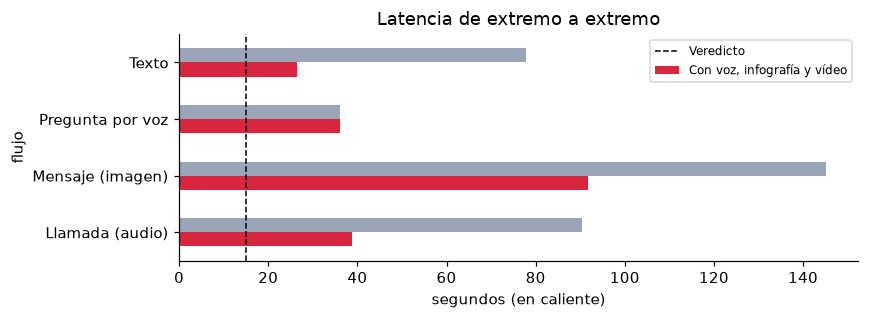

In [4]:
R = pd.DataFrame(records)
lat = R.groupby(["flujo", "pasada"])[["veredicto_s", "total_s", "energia_wh"]].mean().unstack("pasada")
display(lat.round(2))
warm = R[R["pasada"] == "caliente"].groupby("flujo")[["veredicto_s", "total_s"]].mean()

fig, ax = plt.subplots(figsize=(8, 3))
warm[["veredicto_s", "total_s"]].plot.barh(ax=ax, color=["#d7263d", "#9aa5b8"])
ax.axvline(15, ls="--", c="k", lw=1)
ax.set_xlabel("segundos (en caliente)"); ax.legend(["Veredicto", "Con voz, infografía y vídeo"], fontsize=8)
ax.set_title("Latencia de extremo a extremo")
plt.tight_layout()

## 4. Desglose por etapa (en caliente)

,mean,max,count
etapa,,,
Lectura visual,48.53,52.87,4
Razonamiento,31.24,37.53,6
Vídeo-alerta,17.11,19.21,6
Infografía,16.13,16.50,6
Aviso de voz,16.01,18.53,6
Transcripción,11.68,11.68,1
Contexto acústico,1.62,1.62,1
Embedding visual,0.69,0.77,4
Embedding texto,0.11,0.17,6


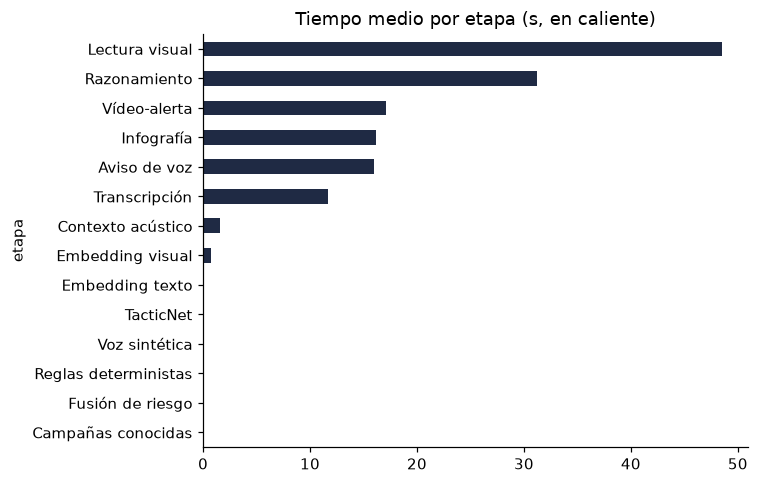

In [5]:
stage_rows = []
for _, r in R[R["pasada"] == "caliente"].iterrows():
    for st, s in r["etapas"].items():
        stage_rows.append({"flujo": r["flujo"], "etapa": st, "s": s})
stages = pd.DataFrame(stage_rows).groupby("etapa")["s"].agg(["mean", "max", "count"]).sort_values("mean", ascending=False)
display(stages.round(2))
stages["mean"].sort_values().plot.barh(figsize=(7, 4.5), color="#1f2a44", title="Tiempo medio por etapa (s, en caliente)")
plt.tight_layout()

## 5. VRAM a lo largo del tiempo

Con 8 GB de VRAM no caben a la vez Qwen2.5-VL (≈ 6 GB), Qwen3 (≈ 6 GB), Whisper (≈ 1,6 GB) y SDXL-Turbo
(≈ 5 GB con *offload*). El gestor de VRAM (`src/diputado/ai/gpu.py`) los turna: el gráfico muestra cómo
la memoria sube y baja sin superar nunca el total.

Pico de VRAM: 6.68 GB de 8.00 GB · potencia media 16 W · máxima 86 W


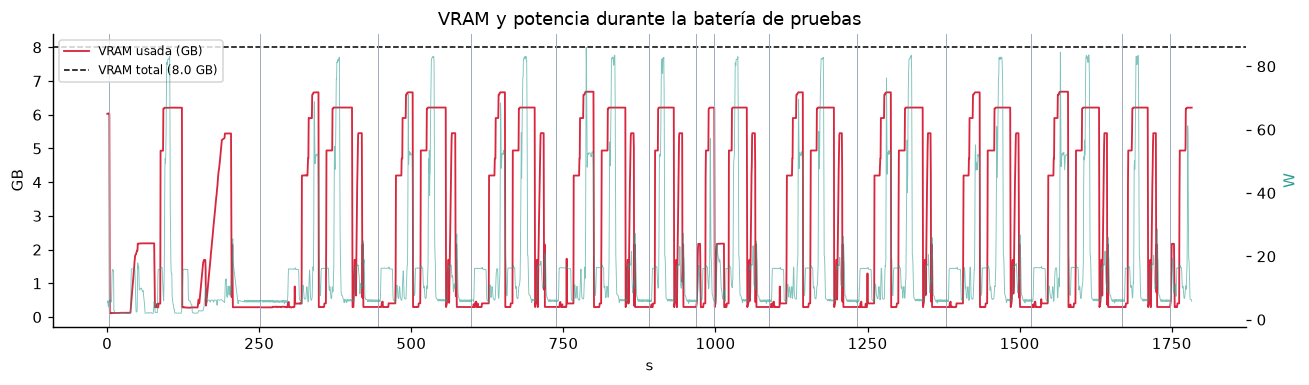

In [6]:
if mon and mon.samples:
    ts, mem, pw, ut = np.array(mon.samples).T
    ts = ts - mon.t0
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.plot(ts, mem, c="#d7263d", lw=1.2, label="VRAM usada (GB)")
    ax.axhline(vram_gb(), c="k", ls="--", lw=1, label=f"VRAM total ({vram_gb():.1f} GB)")
    for t, lab in mon.marks:
        ax.axvline(t - mon.t0, c="#9aa5b8", lw=0.6)
    ax2 = ax.twinx(); ax2.plot(ts, pw, c="#2a9d8f", lw=0.6, alpha=0.6); ax2.set_ylabel("W", color="#2a9d8f")
    ax.set_xlabel("s"); ax.set_ylabel("GB"); ax.legend(loc="upper left", fontsize=8); ax.set_title("VRAM y potencia durante la batería de pruebas")
    plt.tight_layout()
    peak = float(mem.max())
    print(f"Pico de VRAM: {peak:.2f} GB de {vram_gb():.2f} GB · potencia media {pw.mean():.0f} W · máxima {pw.max():.0f} W")
else:
    peak, pw = float("nan"), np.array([float("nan")])

## 6. Coste por análisis en este equipo

In [7]:
eur_kwh = 0.15
e = R[R["pasada"] == "caliente"].groupby("flujo")["energia_wh"].mean()
cost = pd.DataFrame({"energía GPU (Wh)": e, "€ de electricidad por análisis": e / 1000 * eur_kwh})
display(cost.round(5))
display(Markdown(f"Incluso con la infografía y el vídeo, un análisis cuesta **milésimas de euro** en electricidad. "
                 "El notebook 00 usa estas latencias para estimar el coste con un servidor del banco frente a APIs de pago."))

,energía GPU (Wh),€ de electricidad por análisis
flujo,,
Llamada (audio),0.41712,0.00006
Mensaje (imagen),0.72568,0.00011
Pregunta por voz,0.13801,0.00002
Texto,0.36183,0.00005


Incluso con la infografía y el vídeo, un análisis cuesta **milésimas de euro** en electricidad. El notebook 00 usa estas latencias para estimar el coste con un servidor del banco frente a APIs de pago.

In [8]:
bench = {
    "hardware": hardware,
    "gpu_w": float(np.nanmean(pw)) if HAS_CUDA else 0.0,
    "vram_pico_gb": peak,
    "flujos": {f: {"veredicto_s": round(float(warm.loc[f, "veredicto_s"]), 2), "total_s": round(float(warm.loc[f, "total_s"]), 2),
                   "energia_wh": round(float(e.get(f, np.nan)), 3)} for f in warm.index},
    "frio": {f: round(float(v), 2) for f, v in R[R["pasada"] == "frío"].groupby("flujo")["total_s"].mean().items()},
    "etapas": stages["mean"].round(3).to_dict(),
}
(config.ARTIFACTS_DIR / "benchmarks.json").write_text(json.dumps(bench, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(bench["flujos"], ensure_ascii=False, indent=1))

{
 "Llamada (audio)": {
  "veredicto_s": 38.8,
  "total_s": 90.38,
  "energia_wh": 0.417
 },
 "Mensaje (imagen)": {
  "veredicto_s": 91.74,
  "total_s": 145.07,
  "energia_wh": 0.726
 },
 "Pregunta por voz": {
  "veredicto_s": 36.07,
  "total_s": 36.07,
  "energia_wh": 0.138
 },
 "Texto": {
  "veredicto_s": 26.4,
  "total_s": 77.87,
  "energia_wh": 0.362
 }
}


## Conclusiones

In [9]:
top = stages["mean"].head(3)
small = stages.loc[[s for s in stages.index if any(k in s for k in ("Embedding", "TacticNet", "Reglas", "Fusión", "Campañas", "Voz sintética", "Contexto acústico"))], "mean"]
display(Markdown("\n".join([
    f"* En caliente el **veredicto** llega en {warm['veredicto_s'].min():.0f}-{warm['veredicto_s'].max():.0f} s según el flujo; "
    "la voz, la infografía y el vídeo se añaden después, de forma progresiva, sin bloquear la decisión.",
    "* Las etapas más caras son " + ", ".join(f"**{k}** ({v:.1f} s)" for k, v in top.items()) + ". "
    "Gran parte de ese tiempo es **cambiar de modelo en la GPU**: con 8 GB, Qwen2.5-VL y Qwen3 no caben a la vez y "
    "Ollama descarga uno para cargar el otro.",
    f"* Los modelos pequeños (e5, SigLIP2, CLAP, reglas, cabezas Keras) suman {small.sum():.2f} s: viven en CPU y no compiten por VRAM.",
    f"* El pico de VRAM medido es {peak:.1f} GB de {vram_gb():.1f} GB: el gestor de VRAM turna los modelos grandes y "
    "es lo que permite ejecutar **unos 12 modelos** en un portátil.",
    "* En un servidor del banco con una GPU de 24 GB o más, los modelos grandes se quedarían cargados a la vez y "
    "desaparecería el tiempo de cambio de modelo; el notebook 00 usa esa hipótesis para el coste por análisis.",
])))

* En caliente el **veredicto** llega en 26-92 s según el flujo; la voz, la infografía y el vídeo se añaden después, de forma progresiva, sin bloquear la decisión.
* Las etapas más caras son **Lectura visual** (48.5 s), **Razonamiento** (31.2 s), **Vídeo-alerta** (17.1 s). Gran parte de ese tiempo es **cambiar de modelo en la GPU**: con 8 GB, Qwen2.5-VL y Qwen3 no caben a la vez y Ollama descarga uno para cargar el otro.
* Los modelos pequeños (e5, SigLIP2, CLAP, reglas, cabezas Keras) suman 2.51 s: viven en CPU y no compiten por VRAM.
* El pico de VRAM medido es 6.7 GB de 8.0 GB: el gestor de VRAM turna los modelos grandes y es lo que permite ejecutar **unos 12 modelos** en un portátil.
* En un servidor del banco con una GPU de 24 GB o más, los modelos grandes se quedarían cargados a la vez y desaparecería el tiempo de cambio de modelo; el notebook 00 usa esa hipótesis para el coste por análisis.